In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import urllib.request
import tempfile

In [12]:
# Import Data

url = ("https://www.ncbi.nlm.nih.gov/geo/download/"
       "?acc=GSE52778&format=file&file=GSE52778_All_Sample_FPKM_Matrix.txt.gz")

fpkm = pd.read_csv(
    url,
    compression="gzip",
    sep=r"\s+",
    engine="python"
)

In [14]:
# Normalize Data
#log transform to standardize for comparison of all 4 treatments (dexamethasone, 
#albuterol, dexamethasone+albuterol or  left untreated)

#columns of interest
treatment_cols = [
    "Untreated_FPKM",
    "Dex_FPKM",
    "Alb_FPKM",
    "Alb_Dex_FPKM"
]

#df
treatments = fpkm[treatment_cols]

#log transformation
log_data = np.log2(treatments + 1)


In [15]:
#How much does each gene change across treatments?
gene_range = log_data.max(axis=1) - log_data.min(axis=1)

#top 10 genes differences
top10_index = gene_range.nlargest(10).index

top10 = log_data.loc[top10_index].copy()
top10["gene"] = fpkm.loc[top10_index, "gene_short_name"]


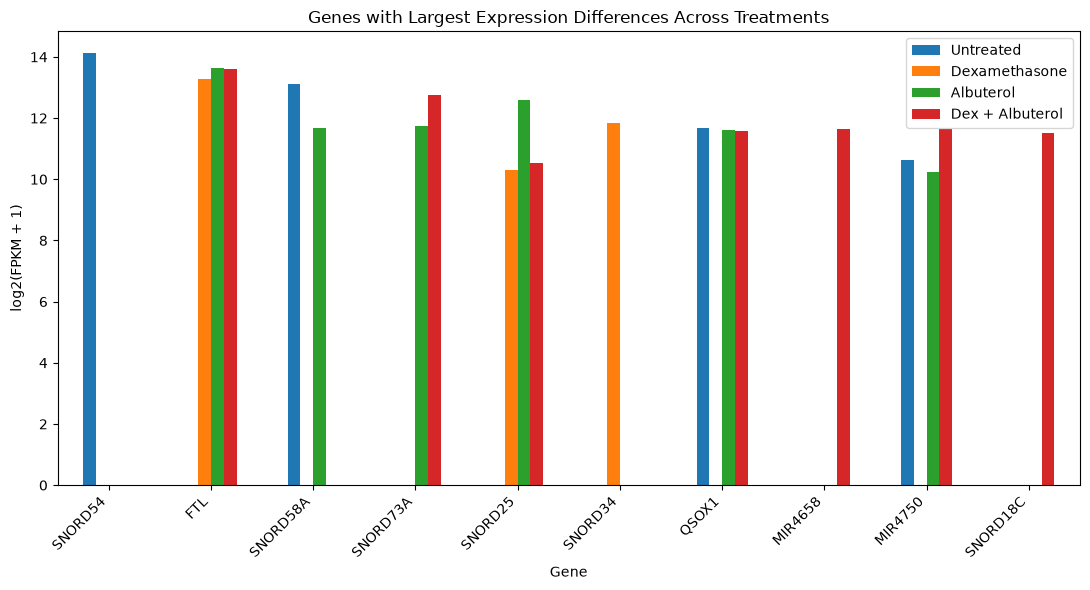

In [16]:
#Plot changes

plot_data = top10.set_index("gene")

plot_data.plot(
    kind="bar",
    figsize=(11, 6)
)

plt.title("Genes with Largest Expression Differences Across Treatments")
plt.xlabel("Gene")
plt.ylabel("log2(FPKM + 1)")
plt.xticks(rotation=45, ha="right")
plt.legend([
    "Untreated",
    "Dexamethasone",
    "Albuterol",
    "Dex + Albuterol"
])
plt.tight_layout()
plt.show()

In [2]:
print("Several genes showed distinct differences in expression across treatments. Some genes like SNORD54 werer highly expressed in untreated cells only, while other like FTL and SNORD25 showed stronger expression in the 3 applied treatment groups. This pattern suggests that treatments have distinct effects on gene expression.")

Several genes showed distinct differences in expression across treatments. Some genes like SNORD54 werer highly expressed in untreated cells only, while other like FTL and SNORD25 showed stronger expression in the 3 applied treatment groups. This pattern suggests that treatments have distinct effects on gene expression.
